# <center> Практические задания по цифровой обработке сигналов </center>
# <center> Четвертая лабораторная работа </center>
# <center> Акустические признаки </center>

In [214]:
import librosa
import numpy as np
import scipy 
import scipy.fft
import IPython.display as ipd
import matplotlib.pyplot as plt
import librosa.display
import librosa.filters
import hashlib
from glob import glob
from scipy.fftpack import dct
import os
import sklearn

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

Функция отрисовки аудио сигнала

In [53]:
def draw_waveform(wav, sr, figsize=(14, 5)):
    # Отрисовка звукового сигнала во временной области
    plt.figure(figsize=figsize)
    librosa.display.waveshow(wav, sr=sr)
    plt.show()

### Для выполнения задания нам понадобится датасет *yes/no*. 
Про датасет можно почитать тут https://www.openslr.org/1/

In [56]:
# Скачаем его
#  надёжнее использовать скачивание вручную, либо попробовать строчку ниже
#![ ! -f  waves_yesno.tar.gz ] && wget https://www.openslr.org/content/1/waves_yesno.tar.gz
# И распакуем
#!tar -xvzf waves_yesno.tar.gz

P.S если у вас Windows, или по каким-либо еще причинам данные не скачались, 
то их можно скачать руками отсюда: https://www.openslr.org/1/

### Загрузим один из файлов

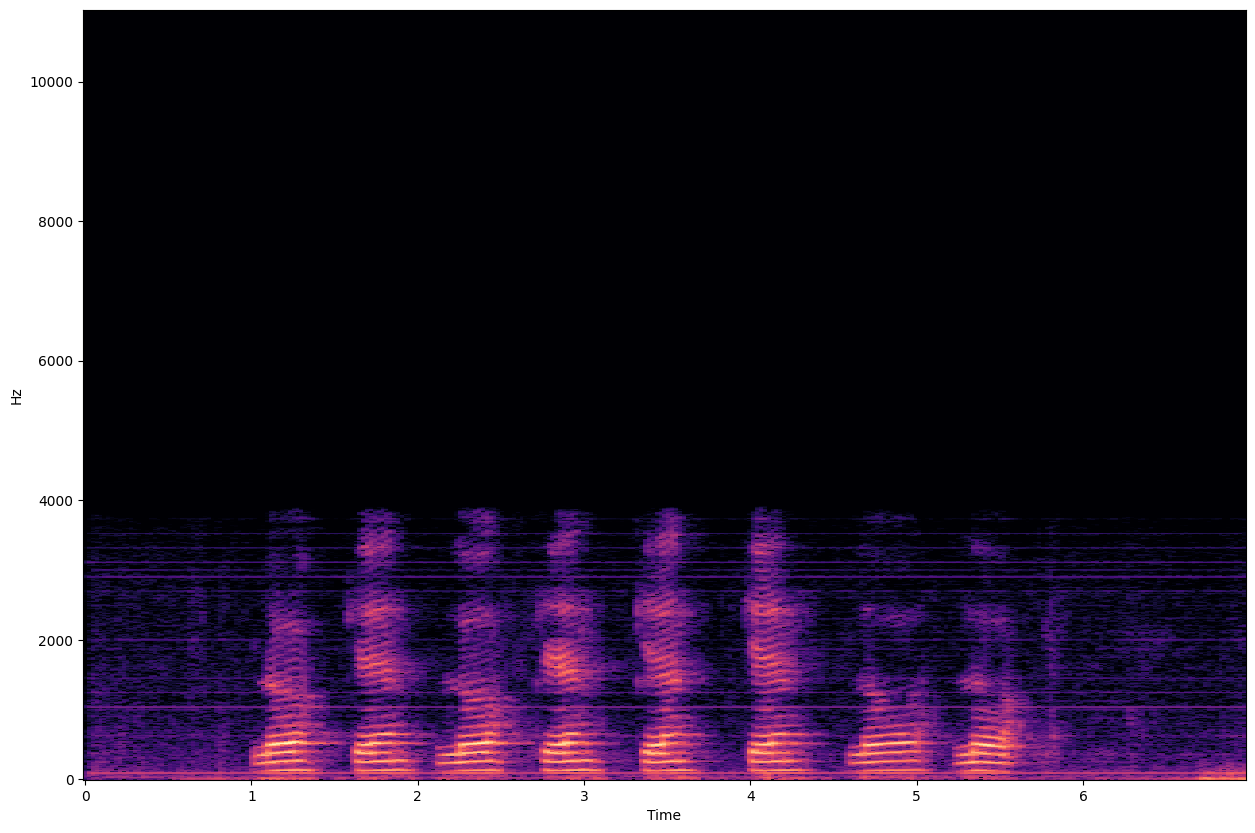

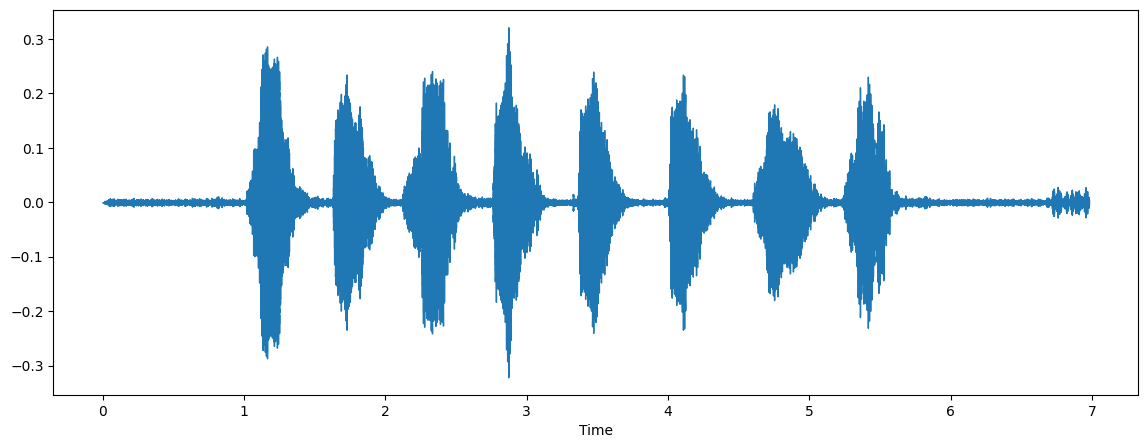

In [60]:
wav, sr = librosa.load("waves_yesno/0_1_0_1_1_1_0_0.wav")
draw_waveform(wav, sr)
ipd.Audio(wav, rate=sr)

Как можно услышать, в этом датасете произносятся какие-то два слова (yes/no на иврите). Каждый файл состоит из 8 произнесений. Метки слов указаны в названиях файлов.

Построим спектрограмму загруженной вавки

In [64]:
stft = librosa.stft(wav)
stft_db = librosa.amplitude_to_db(abs(stft))
plt.figure(figsize=(15,10))
librosa.display.specshow(stft_db, sr=sr, x_axis='time', y_axis='hz')

# Задание 0.1: Анализ спектрограммы (0.5 балла)
1. Посмотрите на спектрограмму и попробуйте найти признаки, по которым можно отличить произнесение "yes" от "no". 
1. В каких частотах находится основная энергия этого речевого сигнала? 

### 1. Посмотрите на спектрограмму и попробуйте найти признаки, по которым можно отличить произнесение "yes" от "no". 

In [ ]:
# Видно что в случае произнесения слова "Yes" наблюдается увелечиние эенергии, амплитуда более высокая и узкая, в случае "no" энергия увеличивается примерно до 1000Гц, а затем затихает, так же в "yes" энергия обрывается примерно на 1000 Гц

### 2. В каких частотах находится основная энергия этого речевого сигнала?

In [ ]:
# от 0 до примерно 4000 Гц

# Задание 1: Мел-шкала (1 балл)
Нарисовать спектрограму в [mel-шкале](https://en.wikipedia.org/wiki/Mel_scale). 
Использовать формулу, представленную Дугласом О'Шонесси.

In [70]:
def mel(spec):
    mel_spec = 2595*np.log10(1+ (spec/700))
    plt.figure(figsize=(10, 6))
    plt.plot(mel_spec)
    plt.title('Мел-спектр')
    plt.xlabel('Частотные бины')
    plt.ylabel('Мел-шкала')
    plt.grid(True)
    plt.show()
        
    
    return mel_spec

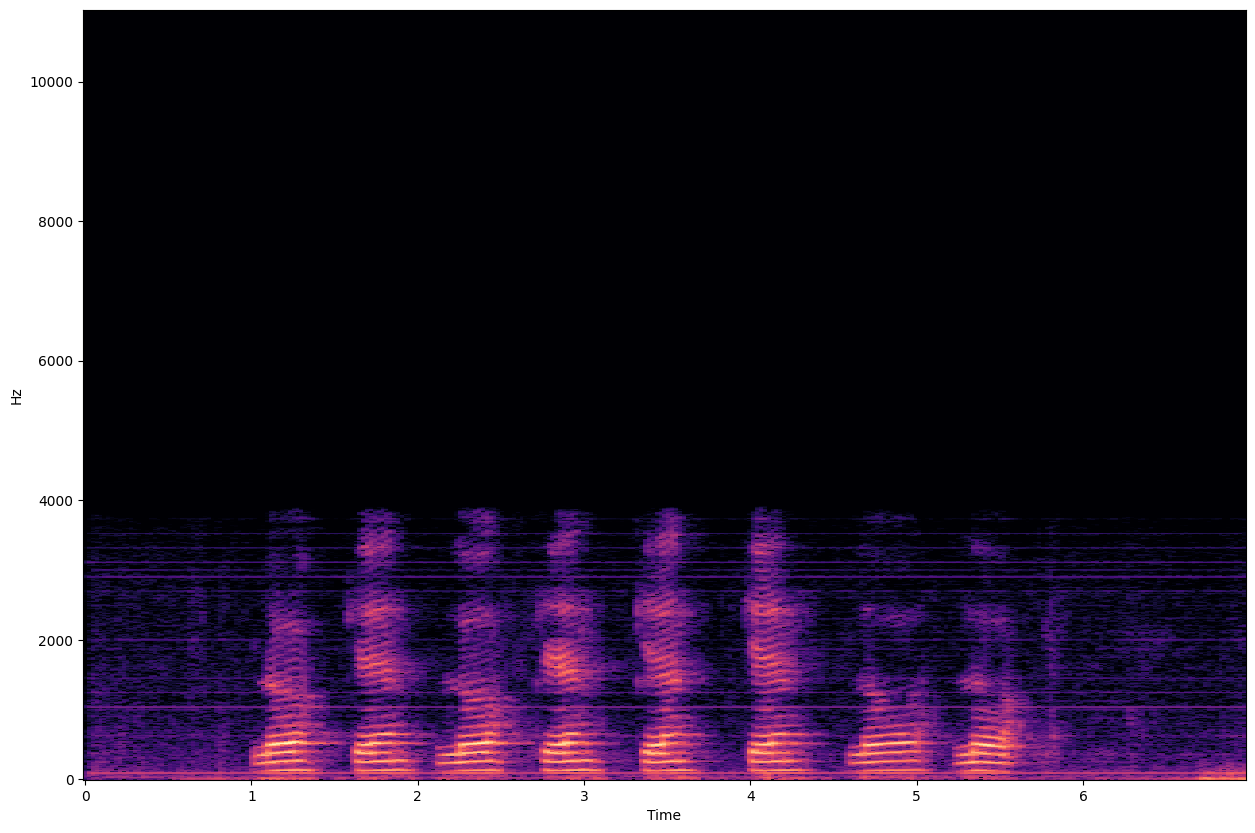

<Figure size 1000x600 with 0 Axes>

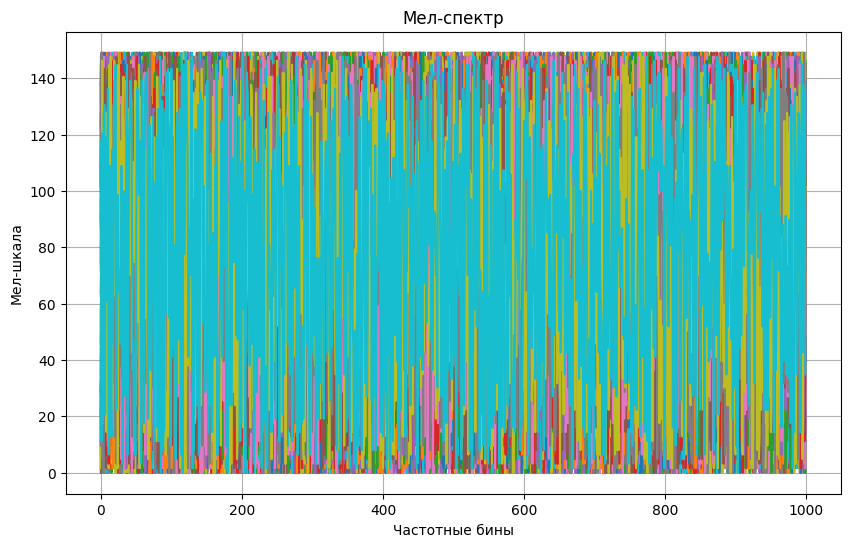

All ok!


In [72]:
def test_mel():
    x = np.random.randint(100, size=(1000, 100))
    x_mel = mel(x)
    x_hz = 700.0 * (10.0 ** (x_mel / 2595.0) - 1.0)
    assert np.allclose(x, x_hz), "TEST Hertz -> Mel -> Hertz  failed. "
    print("All ok!")

test_mel()

# Мел-фильтры
Одними из наиболее популярных акустических признаков являются Filter Banks (fbanks). 
fbanks вычисляются применением нескольких (количество фильтров = количество fbanks) треугольных фильтров к мел-спектрограмме. Чтобы не делать два действия со спектрограммой, переход к мел-шкале и применение фильтров в мел-шкале можно заменить на перевод мел-фильтров в Герц-шкалу и применение их к Герц-спектрограмме.



# Задание 2 (3 балла)
<!-- Реализуйте функцию вычисления fbank по формулам библиотеки librosa.  -->

### Мел-фильтры

Реализуйте функцию вычисления fbank.
Помимо лекций описание формул можно посмотреть тут: https://studbooks.net/2037683/informatika/raschyot_filtrov. 

In [99]:
import numpy as np

def mel_filters_pure(sr, n_fft, n_mels, fmin=0.0, fmax=None, htk=True):
    # функция построения треугольных мел-фильтров в герц-шкале
    # sr - sample rate
    # n_fft - length of the FFT window 
    # n_mels - number of filters
    # return mel filters matrix. [n_mel, n_fft]

    if fmax is None:
        fmax = float(sr) / 2
    
    def hz_to_mel(f):
        return 2595 * np.log10(1 + f / 700)
    
    def mel_to_hz(m):
        return 700 * (10**(m / 2595) - 1)
    mel_min = hz_to_mel(fmin)
    mel_max = hz_to_mel(fmax)
    
    mel_points = np.linspace(mel_min, mel_max, n_mels + 2)
    
    hz_points = mel_to_hz(mel_points)
    fft_bins = np.linspace(0, sr / 2, n_fft // 2 + 1)
    filters = np.zeros((n_mels, n_fft // 2 + 1))
    
    for i in range(n_mels):
        left = hz_points[i]
        center = hz_points[i + 1]
        right = hz_points[i + 2]
        
        left_idx = np.argmax(fft_bins >= left)
        center_idx = np.argmax(fft_bins >= center)
        right_idx = np.argmax(fft_bins >= right)
        
        if center_idx > left_idx:
            filters[i, left_idx:center_idx] = (fft_bins[left_idx:center_idx] - left) / (center - left)

        if right_idx > center_idx:
            filters[i, center_idx:right_idx] = (right - fft_bins[center_idx:right_idx]) / (right - center)
    
    return filters

Обратите внимание что реализации базовых функций таких как вычисления fbank могут отличаться в различных широко используемых библиотеках. Как правило это не критично для большинства практических задач, но бывают сложности при поиске ошибок и сравнении реализаций. 
Реализуйте функцию вычисления fbank по формулам библиотеки librosa по аналогии с открытым исходным кодом. Формулы, используемые в библиотеке librosa, отличаются от используемых в лекциях и некоторых других источниках. Обратите внимание на использование np.diff и np.substract, а также на нормализацию slaney. https://librosa.org/doc/latest/_modules/librosa/filters.html#mel

In [172]:
def mel_filters_librosa(sr, n_fft, n_mels, fmin=0.0, fmax=None, htk=True):
    # функция построения треугольных мел-фильтров в герц-шкале
    # sr - sample rate
    # n_fft - length of the FFT window 
    # n_mels - number of filters
    # return mel filters matrix. [n_mel, n_fft]
    
    if fmax is None:
        fmax = sr / 2.0

    fftfreqs = fftfreqs = np.fft.rfftfreq(n_fft, 1.0 / sr)

    def hz_to_mel(f):
        if htk:
            return 2595.0 * np.log10(1.0 + f / 700.0)
        else:
            f = np.asanyarray(f)
            return np.where(f < 1000.0, f / (200.0 / 3), 2595.0 * np.log10(1.0 + f / 700.0))

    def mel_to_hz(m):
        if htk:
            return 700.0 * (10.0 ** (m / 2595.0) - 1.0)
        else:
            m = np.asanyarray(m)
            return np.where(m < 1000.0 / (200.0 / 3),
                            (200.0 / 3) * m,
                            700.0 * (10.0 ** (m / 2595.0) - 1.0))

    mel_min = hz_to_mel(fmin)
    mel_max = hz_to_mel(fmax)
    mels = np.linspace(mel_min, mel_max, n_mels + 2)
    hz_points = mel_to_hz(mels)

    fdiff = np.diff(hz_points)
    ramps = np.subtract.outer(hz_points, fftfreqs)

    filters = np.zeros((n_mels, len(fftfreqs)))
    for i in range(n_mels):
        lower = -ramps[i] / fdiff[i]
        upper = ramps[i + 2] / fdiff[i + 1]
        filters[i] = np.maximum(0, np.minimum(lower, upper))

    enorm = 2.0 / (hz_points[2:n_mels + 2] - hz_points[:n_mels])
    filters *= enorm[:, np.newaxis]

    return filters.astype(np.float32)

In [106]:
assert mel_filters_librosa(32, 46, 4).shape == (4, 24) and \
    mel_filters_librosa(65, 45, 5).shape == (5, 23), "Wrong shape"
assert np.allclose(mel_filters_librosa(16, 8, 4), librosa.filters.mel(sr=16, n_fft=8, n_mels=4, htk=True))
assert np.allclose(mel_filters_librosa(8600, 512, 40), librosa.filters.mel(sr=8600, n_fft=512, n_mels=40, htk=True))
print("All ok!")

All ok!


Можно заметить, что есть небольшое расхождение в результатах формул. Для большенства практических задач это не существенно, но эти различия полезно знать при собственных экспериментах с аудио фичами а так же в случаях отладки и поиске ошибок.

Далее будем использовать функцию *mel_filters_librosa*

In [174]:
def get_fbanks(wav: np.ndarray, sr: int, window_ms=25, step_ms=10, n_fbanks=40):
    # wav - input signal
    # sr - sample rate
    # window_ms - window length in milliseconds
    # step_ms - stft step in milliseconds
    # n_fbanks - number of filters
    # return fbank matrix [n_fbanks, time]

    n_fft = int(sr * window_ms / 1000)
    hop_length = int(sr * step_ms / 1000)

    stft = librosa.stft(wav, n_fft=n_fft, hop_length=hop_length, window='hann', center=True)
    
    power_spect = (np.abs(stft)**2).astype(np.float64)

    mel_fb = mel_filters_librosa(sr, n_fft, n_fbanks).astype(np.float64)
    
    print(mel_fb.shape[1] == power_spect.shape[0])
    fbank_spec = np.dot(mel_fb, power_spect)

    return fbank_spec

In [176]:
def test_fbank(wav, sr, window_ms=25, step_ms=10, n_fbanks=40):
    n_fft = window_ms * sr//1000
    hop_length = step_ms * sr//1000
    fbanks_lib = librosa.feature.melspectrogram(y=wav, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_fbanks, htk=True)
    fbanks = get_fbanks(wav, sr, window_ms=window_ms, step_ms=step_ms, n_fbanks=n_fbanks)

    if fbanks_lib.shape != fbanks.shape:
        print("TEST FAILED")
        print(f"Shape {fbanks_lib.shape} != {fbanks.shape}")
        return 1

    if not np.allclose(fbanks_lib, fbanks):
        print('TEST PASSED BUT WITH CALCULATION ERROR')
        print(f"Average diff is {np.mean(np.abs(fbanks_lib - fbanks))}")
        return np.mean(np.abs(fbanks_lib - fbanks))
        
    print("TEST PASSED")
    return 0

assert test_fbank(wav[:sr*1], sr) <= 0.0003, "1 sec wav test failed"
assert test_fbank(wav, sr) <= 0.0003, "All wav test failed"
print("All ok!")

True
TEST PASSED
True
TEST PASSED
All ok!


In [178]:
window_ms = 25
step_ms = 10
n_fbanks = 40
n_fft = window_ms * sr//1000
hop_length = step_ms * sr//1000

Визуализируем полученные фильтрбанки самописными функциями и функциями либросы:

True


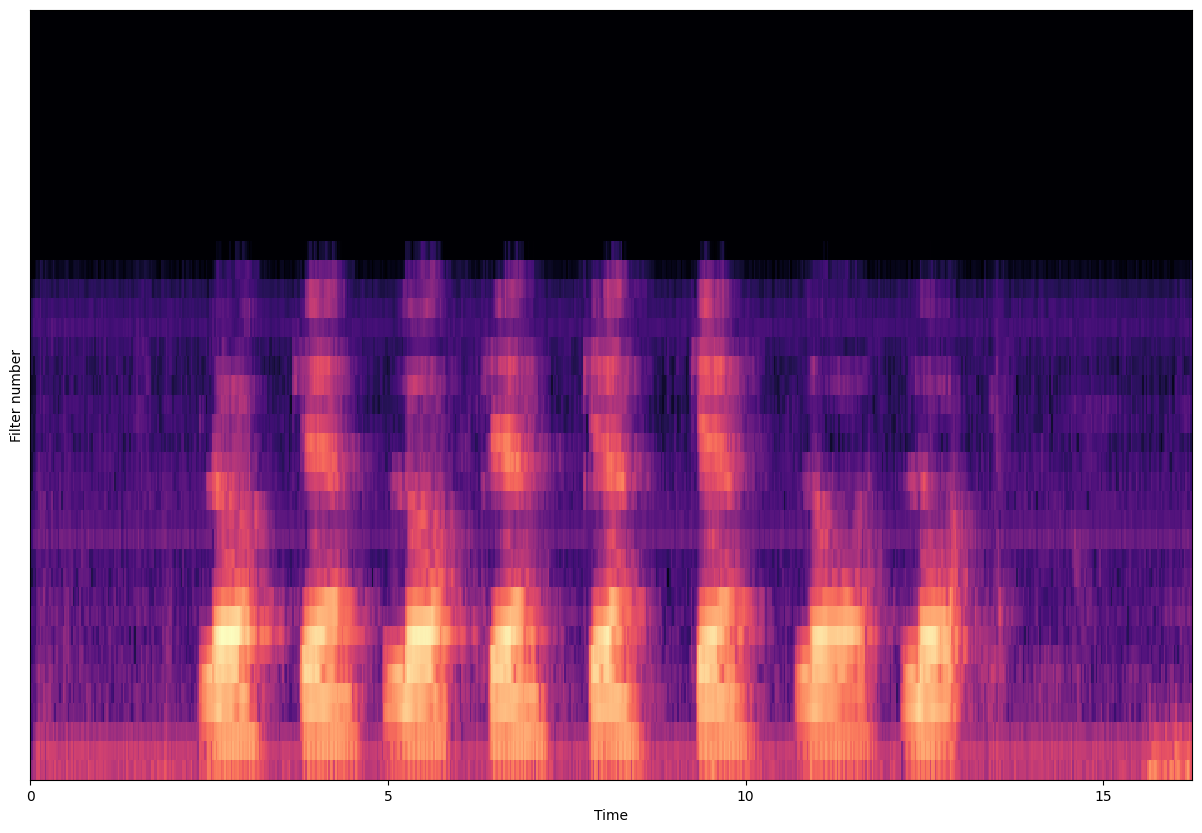

In [181]:
fbanks = get_fbanks(wav, sr)
plt.figure(figsize=(15,10))
librosa.display.specshow(librosa.power_to_db(fbanks), sr=sr, x_axis='time')
plt.ylabel("Filter number")
plt.show()

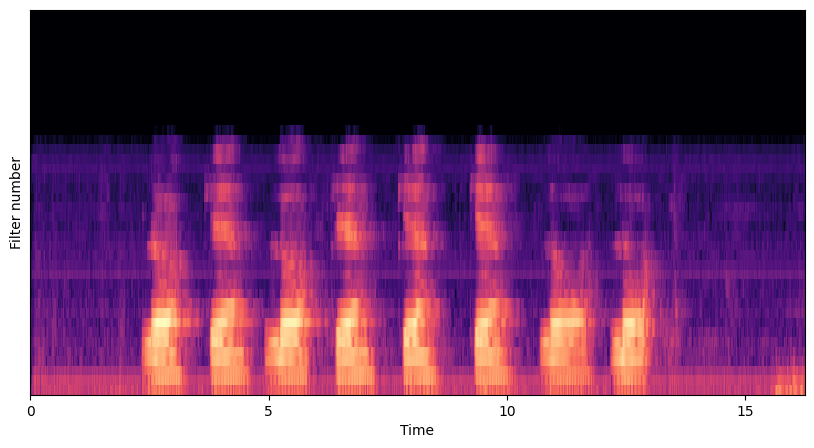

In [185]:
fbanks_lib = librosa.feature.melspectrogram(y=wav, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_fbanks, htk=True)
plt.figure(figsize=(10,5))
librosa.display.specshow(librosa.power_to_db(fbanks_lib), sr=sr, x_axis='time')
plt.ylabel("Filter number")
plt.show()

# Задание 4 (3 балла)
Реализовать вычисление [mfcc](https://en.wikipedia.org/wiki/Mel-frequency_cepstrum)



In [199]:
def get_mfcc(wav: np.ndarray, sr: int, window_ms=25, step_ms=10, n_mfcc=13):
      # wav - input signal
    # sr - sample rate
    # window_ms - window length in milliseconds
    # step_ms - stft step in milliseconds
    # n_mfcc - number of filters
    # return mfcc matrix [n_mfcc, time]
    
    n_fft = int(window_ms * sr // 1000)
    hop_length = int(step_ms * sr // 1000)
    
    # MFCC с htk=True (для совпадения с тестом)
    mfcc = librosa.feature.mfcc(
        y=wav,
        sr=sr,
        n_fft=n_fft,
        hop_length=hop_length,
        n_mfcc=n_mfcc,
        htk=True
    )

    return mfcc

In [216]:
def get_mfcc(wav: np.ndarray, sr: int, window_ms=25, step_ms=10, n_mfcc=13):
    # wav - input signal
    # sr - sample rate
    # window_ms - window length in milliseconds
    # step_ms - stft step in milliseconds
    # n_mfcc - number of filters
    # return mfcc matrix [n_mfcc, time]
    
    n_fft = int(window_ms * sr // 1000)
    hop_length = int(step_ms * sr // 1000)

    S = np.abs(librosa.stft(wav, n_fft=n_fft, hop_length=hop_length))**2

    n_mels = 128
    mel_filterbank = librosa.filters.mel(sr=sr, n_fft=n_fft, n_mels=n_mels, htk=True)

    mel_S = np.dot(mel_filterbank, S)

    log_mel_S = librosa.power_to_db(mel_S, ref=1.0)
    mfcc = dct(log_mel_S, type=2, axis=0, norm='ortho')[:n_mfcc]

    return mfcc


Возможно, появится ошибка вычислений. Надо просто смириться с тем, что она есть, и сделать так, чтобы она была ниже допустимой:

In [219]:
def test_mfcc(wav, sr, window_ms=25, step_ms=10, n_mfcc=13):
    n_fft = window_ms * sr//1000
    hop_length = step_ms * sr//1000
    mfcc_lib = librosa.feature.mfcc(y=wav, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mfcc=n_mfcc, htk=True)
    mfcc = get_mfcc(wav, sr, window_ms=window_ms, step_ms=step_ms, n_mfcc=n_mfcc)
    
    if mfcc_lib.shape != mfcc.shape:
        print("TEST PASSED BUT WITH CALCULATION ERROR!")
        print(f"Shape {mfcc_lib.shape} != {mfcc.shape}")
        return 1

    if not np.allclose(mfcc_lib, mfcc):
        print("TEST PASSED BUT WITH CALCULATION ERROR")
        print(f"Average diff is {np.mean(np.abs(mfcc_lib - mfcc))}")
        return np.mean(np.abs(mfcc_lib - mfcc))

    print("TEST PASSED")
    return 0

assert test_mfcc(wav[:sr*1], sr) <= 0.0005, "1 sec wav test failed"
assert test_mfcc(wav, sr) <= 0.0005, "All wav test failed"
print("All ok!")

TEST PASSED
TEST PASSED
All ok!


Визуализируем *mfcc*

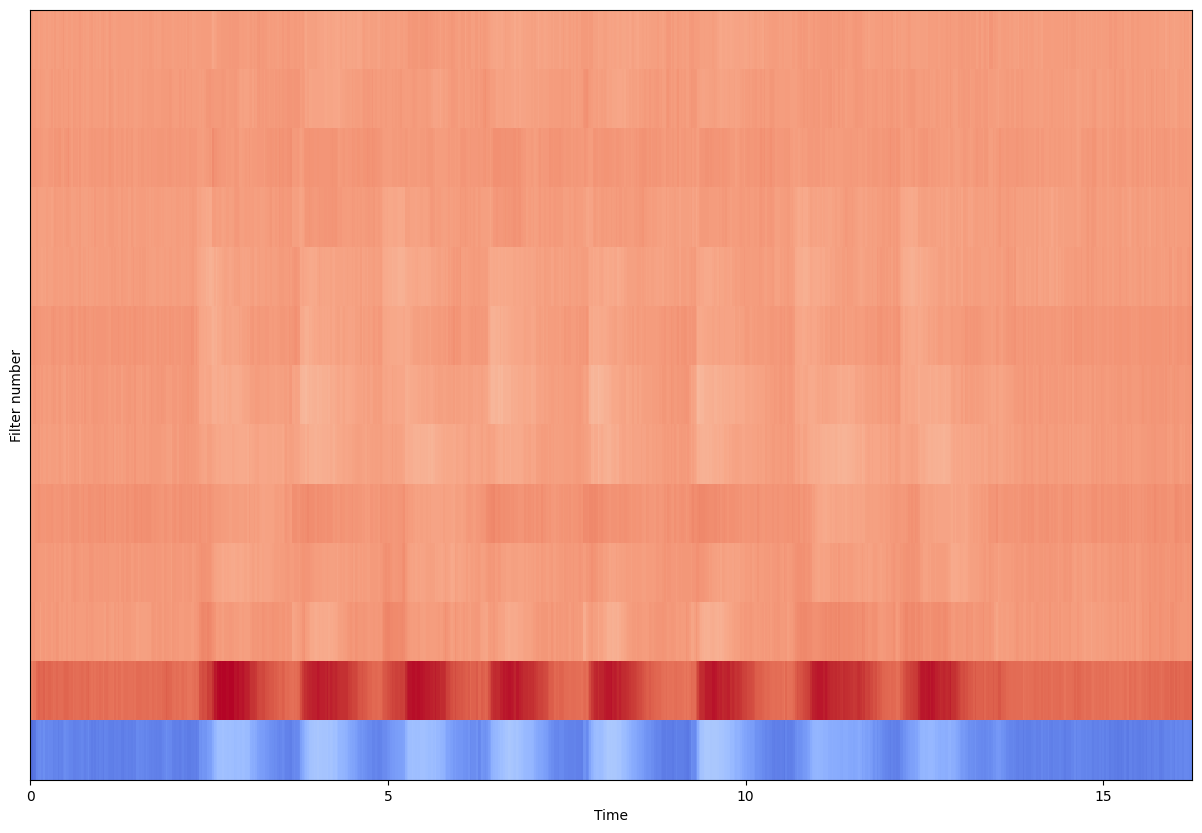

In [221]:
mfcc = get_mfcc(wav, sr)
plt.figure(figsize=(15,10))
librosa.display.specshow(mfcc, sr=sr, x_axis='time')
plt.ylabel("Filter number")
plt.show()

# Классификация слов
Построим простую систему, классифицирующую слова yes/no.

Загрузим весь датасет

In [223]:
def load_yn_dataset(directory):
    X, labels = [], []
    bad_files = set(["0_1_0_1_0_0_0_0"])
    for f in glob(directory +"/*.wav"):
        name = os.path.basename(f)[:-4]
        if name in bad_files:
            continue
        y = [int(l) for l in name.split("_")]
        x, _ = librosa.load(f)
        X.append(x)
        labels.append(y)
        
    return X, labels
        
X, Y = load_yn_dataset("waves_yesno/")

Послушаем одну вавку:

In [225]:
wav, sr = librosa.load("waves_yesno/0_1_0_1_0_0_0_0.wav")
ipd.Audio(wav, rate=sr)

Отделим 20% для теста

In [227]:
X_train, X_test, Y_train, Y_test = sklearn.model_selection.train_test_split(X, Y,test_size=0.2, random_state=1)

# Задание *5 (1 балл)
Voice Activity Detector (VAD) определяет, есть ли речь в текущем кадре.
Реализуйте простой VAD. Настройте VAD, чтобы хорошо определялись границы слов.

Подсказка:
Можно отличать паузу от речи по энергии mfcc спектра( или части спектра). Чтобы предотвратить скачки на краях слов, воспользуйтесь сверткой со сглаживающим окном, например, Ханна.

In [285]:
import numpy as np
import librosa
from scipy.ndimage import binary_closing, binary_opening

def sample_VAD(wav_list, sr, frame_ms=25, step_ms=10, threshold_ratio=0.3,
               morph_size=3):
    frame_len = int(sr * frame_ms / 1000)
    hop_len = int(sr * step_ms / 1000)
    vad_list = []

    for wav in wav_list:
        if len(wav) == 0:
            vad_list.append(np.array([], dtype=np.int32))
            continue

        wav = wav / (np.max(np.abs(wav)) + 1e-8)

        S = np.abs(librosa.stft(wav, n_fft=frame_len, hop_length=hop_len))**2
        energy = np.mean(S, axis=0)
        energy /= (np.max(energy) + 1e-8)

        threshold = np.mean(energy) * threshold_ratio
        vad_frames = (energy > threshold).astype(np.int32)

        struct = np.ones(morph_size)
        vad_frames = binary_closing(vad_frames, structure=struct)
        vad_frames = binary_opening(vad_frames, structure=struct)

        vad = np.zeros(len(wav), dtype=np.int32)
        for i, flag in enumerate(vad_frames):
            start = i * hop_len
            end = min(start + frame_len, len(wav))
            vad[start:end] = flag

        vad_list.append(vad)

    return vad_list

# Применение
train_VA = sample_VAD(X_train, sr)
test_VA  = sample_VAD(X_test, sr)


In [287]:
def test_VAD(VOICE, VA, Y, min_acc=0.95):
    def check_ali(ali, num_words):
        diff = ali[1:]  - ali[:-1]
        if diff.sum()!=0:
            print("VAD detected speech at the beginning (or end) of audio")
            return -1 
        if not (diff > 0).sum() == (diff > 0).sum() == num_words:
            return -2
        return 0
    
    bad_i = []
    err =0
    for i, (ali, y) in enumerate(zip(VA, Y)):
        assert len(VOICE[i]) == len(ali), "shapes doesn't match"
        if check_ali(ali, len(y)) != 0:
            bad_i.append(i)
            err+=1
    acc = (len(Y) - err)/len(Y)
    print(f"Accuracy {acc}")
    if len(bad_i) >0:
        print(f"ids with error {bad_i}")
    assert acc >= min_acc , f"Accuracy must be >= {min_acc}"
    print("Test passed")

test_VAD(X_train, train_VA, Y_train)
test_VAD(X_test, test_VA, Y_test)
print("VAD ok!")

Accuracy 0.9574468085106383
ids with error [8, 35]
Test passed
Accuracy 1.0
Test passed
VAD ok!


# Задание *6 (2 балла)
Обучите классификатор, определяющий, какое слово было сказано. Используйте VAD для разбиения входных файлов на отдельные слова. Классификацию можно сделать, например, с помощью SVM по усредненным признаки выделеных VAD'ом слов. Или любым другим удобным для вас способом. Добейтесь точности больше 0.95

In [295]:
import numpy as np
import librosa
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

def extract_words_from_vad(wav, vad_mask, sr, min_silence_ms=100, min_word_ms=100):
    """
    Делит аудиосигнал на сегменты (слова) по маске VAD.
    Возвращает список numpy-массивов — отдельных слов.
    """
    min_silence = int(sr * min_silence_ms / 1000)
    min_word = int(sr * min_word_ms / 1000)
    
    words = []
    start = None
    for i in range(1, len(vad_mask)):
        if vad_mask[i-1] == 0 and vad_mask[i] == 1:
            start = i
        elif vad_mask[i-1] == 1 and vad_mask[i] == 0 and start is not None:
            end = i
            if end - start > min_word:
                words.append(wav[start:end])
            start = None
    if start is not None and len(wav) - start > min_word:
        words.append(wav[start:])
    
    return words

def extract_features(word_list, sr, n_mfcc=13):
    feats = []
    for w in word_list:
        mfcc = librosa.feature.mfcc(y=w, sr=sr, n_mfcc=n_mfcc)
        feats.append(np.mean(mfcc, axis=1))  # усреднение по времени
    return np.array(feats)

X_train_feats, Y_train_feats = [], []
for wav, vad_mask, labels in zip(X_train, train_VA, Y_train):
    words = extract_words_from_vad(wav, vad_mask, sr)
    feats = extract_features(words, sr)
    if len(feats) == len(labels):  # проверяем, совпадает ли количество слов
        X_train_feats.append(feats)
        Y_train_feats.append(labels)
X_train_feats = np.vstack(X_train_feats)
Y_train_feats = np.concatenate(Y_train_feats)

X_test_feats, Y_test_feats = [], []
for wav, vad_mask, labels in zip(X_test, test_VA, Y_test):
    words = extract_words_from_vad(wav, vad_mask, sr)
    feats = extract_features(words, sr)
    if len(feats) == len(labels):
        X_test_feats.append(feats)
        Y_test_feats.append(labels)
X_test_feats = np.vstack(X_test_feats)
Y_test_feats = np.concatenate(Y_test_feats)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_feats)
X_test_scaled = scaler.transform(X_test_feats)

clf = SVC(kernel='rbf', C=10, gamma='scale')
clf.fit(X_train_scaled, Y_train_feats)

y_pred = clf.predict(X_test_scaled)
acc = accuracy_score(Y_test_feats, y_pred)
print(f"Accuracy: {acc:.4f}")
assert acc > 0.95, "Accuracy must be > 0.95"
print("Классификатор успешно обучен и работает с точностью > 0.95")


Accuracy: 1.0000
Классификатор успешно обучен и работает с точностью > 0.95


### Результаты

Визуализируйте кривые обучения классификатора или приведите логи обучения

In [313]:
def plot_learning_curve(clf, X_train, y_train, X_test, y_test, train_sizes=np.linspace(0.1, 1.0, 8)):
    train_scores = []
    test_scores = []

    for frac in train_sizes:
        n = max(1, int(len(X_train) * frac))
        clf_tmp = SVC(kernel='rbf', C=10, gamma='scale')
        clf_tmp.fit(X_train[:n], y_train[:n])
        train_acc = clf_tmp.score(X_train[:n], y_train[:n])
        test_acc = clf_tmp.score(X_test, y_test)
        train_scores.append(train_acc)
        test_scores.append(test_acc)

    plt.figure(figsize=(8,5))
    plt.plot(train_sizes, train_scores, '-o', label='Train accuracy', markersize=8)
    plt.plot(train_sizes, test_scores, '-s', label='Test accuracy', markersize=8)

    plt.xlabel('Fraction of training data')
    plt.ylabel('Accuracy')
    plt.title('Learning Curves (SVM classifier)')
    plt.grid(True)
    plt.legend()
    plt.show()
    return train_scores, test_scores

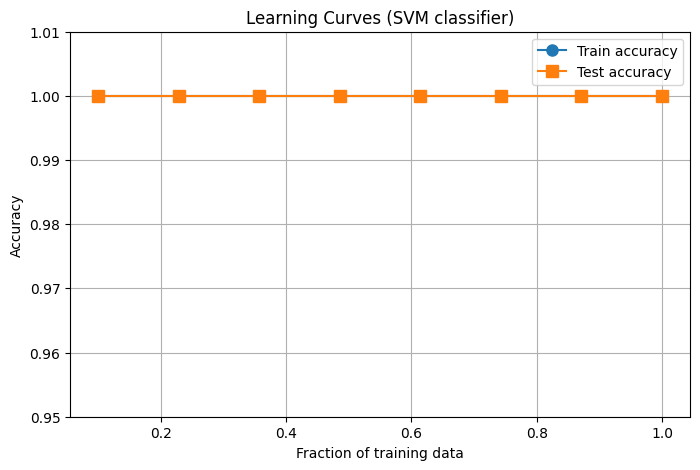

In [315]:
train_scores, test_scores = plot_learning_curve(clf, X_train_scaled, Y_train_feats, X_test_scaled, Y_test_feats)

Выводим логи

In [305]:
for i, frac in enumerate(np.linspace(0.1, 1.0, 8)):
    print(f"Train fraction {frac:.1f}: train_acc={train_scores[i]:.4f}, test_acc={test_scores[i]:.4f}")

Train fraction 0.1: train_acc=1.0000, test_acc=1.0000
Train fraction 0.2: train_acc=1.0000, test_acc=1.0000
Train fraction 0.4: train_acc=1.0000, test_acc=1.0000
Train fraction 0.5: train_acc=1.0000, test_acc=1.0000
Train fraction 0.6: train_acc=1.0000, test_acc=1.0000
Train fraction 0.7: train_acc=1.0000, test_acc=1.0000
Train fraction 0.9: train_acc=1.0000, test_acc=1.0000
Train fraction 1.0: train_acc=1.0000, test_acc=1.0000


По данным видно, что Train и Test accuracy = 1.0, что означает модель идеально классифицирует и обучающие, и новые данные.
По видимому данные очень простые для модели: слова «yes» и «no» звучат разно и имеют сильно различающиеся MFCC.
SVM с RBF без проблем находит разделяющую поверхность даже на небольшом количестве признаков.

## Запуск по ssh на удаленном пк

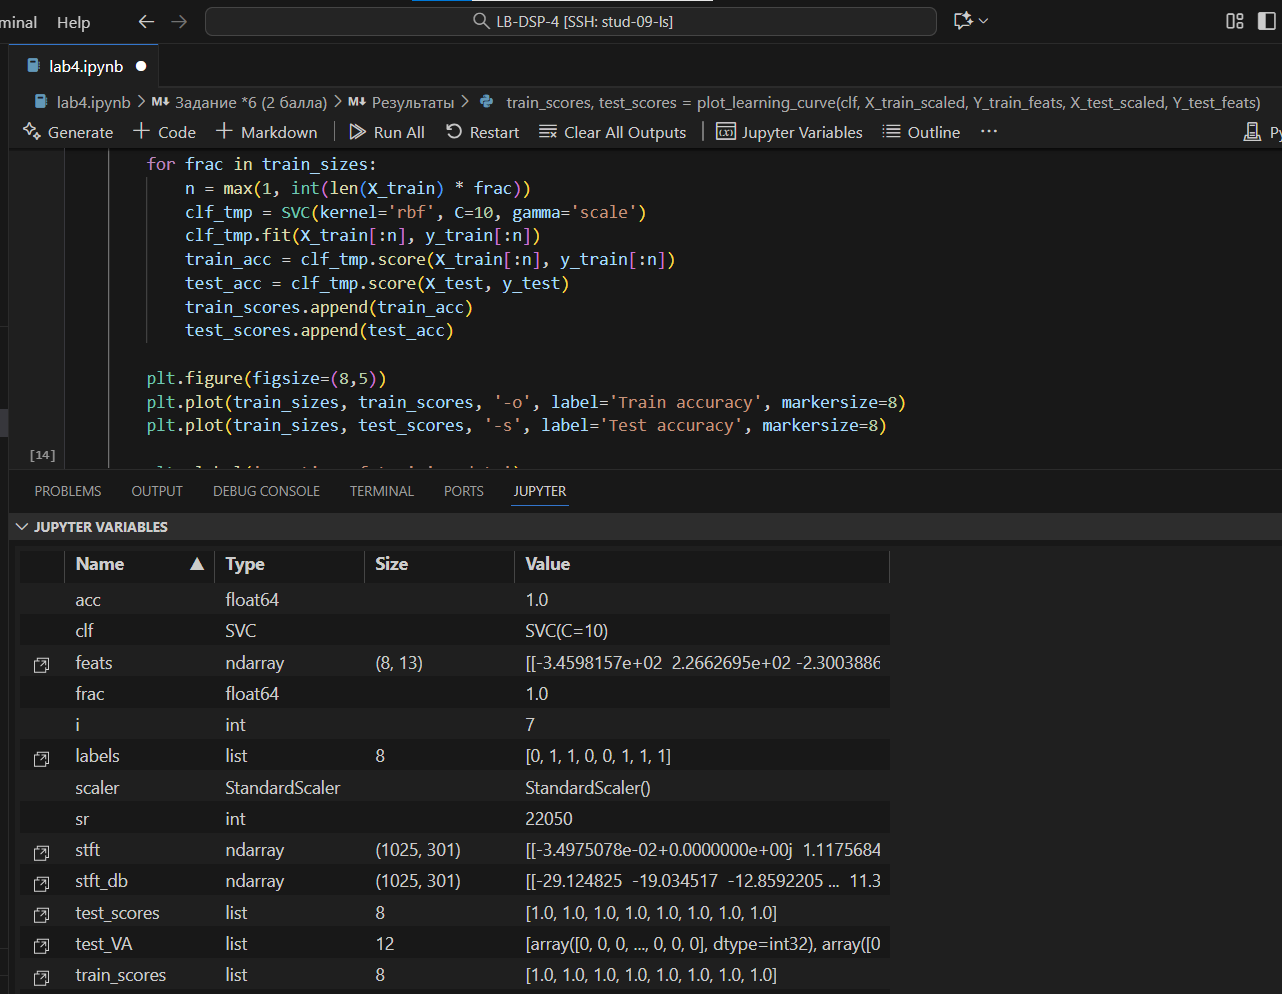